In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import joblib  # For saving and loading scalers
import matplotlib.pyplot as plt  # For plotting
import os
import warnings
warnings.filterwarnings("ignore")

In [29]:
# Function to create dataset
def create_dataset(data, lookback=30, horizon=5):
    X, y = [], []
    for i in range(lookback, len(data) - horizon):
        X.append(data[i - lookback:i, 0])
        y.append(data[i + horizon - 1, 0])  # Only the fifth day
    return np.array(X), np.array(y)

# Function to build LSTM model
def build_lstm_model(lookback, horizon):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(lookback, 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))  # Predict only one value (fifth day)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load your stock data
stocks = pd.read_csv('Top_4_Stocks.csv')
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks.set_index('Date', inplace=True)

# Parameters
lookback = 10  # Number of past days to consider
horizon = 5    # Predict the fifth day
models_dict = {}

In [32]:
stocks.columns[0]

'HDFCBANK.NS'

In [33]:
stocks[stocks.columns[0]]

Date
2015-01-01     440.343475
2015-01-02     446.471832
2015-01-05     442.702271
2015-01-06     435.810760
2015-01-07     437.082672
                 ...     
2025-03-17    1710.400024
2025-03-18    1710.400024
2025-03-19    1744.099976
2025-03-20    1768.750000
2025-03-21    1770.349976
Name: HDFCBANK.NS, Length: 2524, dtype: float64

In [ ]:
# Iterate over each stock (assuming each stock is in a separate column)
for stock_name in [stocks.columns[0]]:
    # print(stock_name)
    prices = stocks[stock_name].values.reshape(-1, 1)

    training_dates = []
    testing_dates = []
    start_date = stocks.index[0]
    end_date = stocks.index[-1]

    # Generate training and testing date ranges
    while start_date + pd.DateOffset(years=4) <= end_date:
        training_dates.append((start_date, start_date + pd.DateOffset(years=3)))
        testing_dates.append((start_date + pd.DateOffset(years=3), start_date + pd.DateOffset(years=4)))
        start_date += pd.DateOffset(years=1)

    # Train and test for each date range
    for train_date, test_date in zip(training_dates, testing_dates):
        # Split data into training and testing sets
        train_data = stocks.loc[train_date[0]:train_date[1]][stock_name].values.reshape(-1, 1)
        test_data = stocks.loc[test_date[0]:test_date[1]][stock_name].values.reshape(-1, 1)

        # Scale the training data and use the same scaler for the test data
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_train_data = scaler.fit_transform(train_data)
        scaled_test_data = scaler.transform(test_data)

        # Create datasets
        X_train, y_train = create_dataset(scaled_train_data, lookback, horizon)
        X_test, y_test = create_dataset(scaled_test_data, lookback, horizon)

        # Reshape data for LSTM
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

        # Build and train the model
        model = build_lstm_model(lookback, horizon)
        model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), verbose=0)

        # Save the model and scaler with a meaningful name
        model_name = f"{stock_name}_{train_date[0].strftime('%Y%m%d')}_{test_date[0].strftime('%Y%m%d')}"
        model.save(f"models/{model_name}.h5")
        joblib.dump(scaler, f"models/{model_name}_scaler.pkl")  # Save the scaler
        models_dict[model_name] = (model, scaler)

        print(f"Model and scaler saved: {model_name}")

In [ ]:
# Function to load a model and scaler and predict the fifth day
def predict_fifth_day(model_name, last_sequence):
    """
    Predict the fifth day of stock prices using a saved model and scaler.
    
    Args:
        model_name (str): Name of the saved model (e.g., 'StockA_20150101_20180101').
        last_sequence (np.array): Last `lookback` days of stock prices (shape: [lookback, 1]).
    
    Returns:
        float: Predicted stock price for the fifth day.
    """
    # Load the model
    model = load_model(f"{model_name}.h5")

    # Load the scaler
    scaler = joblib.load(f"{model_name}_scaler.pkl")

    # Scale the last sequence
    scaled_last_sequence = scaler.transform(last_sequence)

    # Reshape for LSTM input
    scaled_last_sequence = np.reshape(scaled_last_sequence, (1, lookback, 1))

    # Make prediction
    scaled_prediction = model.predict(scaled_last_sequence)

    # Reverse scaling to get actual stock price
    prediction = scaler.inverse_transform(scaled_prediction)
    return prediction[0][0]


# Function to evaluate model and plot predictions continuously
def evaluate_and_plot_continuous(model_name, test_data, test_dates, lookback, horizon):
    """
    Evaluate the model on the test data continuously and plot predictions vs actual values.
    
    Args:
        model_name (str): Name of the saved model (e.g., 'StockA_20150101_20180101').
        test_data (np.array): Test data for evaluation.
        test_dates (pd.DatetimeIndex): Dates corresponding to the test data.
        lookback (int): Number of past days to consider.
        horizon (int): Horizon for prediction (5 for fifth day).
    """
    # Load the model
    model = load_model(f"{model_name}.h5")

    # Load the scaler
    scaler = joblib.load(f"{model_name}_scaler.pkl")

    # Prepare the test data
    scaled_test_data = scaler.transform(test_data)
    X_test, y_test = create_dataset(scaled_test_data, lookback, horizon)

    # Reshape data for LSTM
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Make predictions
    scaled_predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(scaled_predictions)  # Reverse scaling for predictions
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))   # Reverse scaling for actual values

    # Calculate MSE (before scaling)
    mse = mean_squared_error(actual, predictions)
    print(f"Mean Squared Error (MSE) for {model_name}: {mse}")

    # Get dates for the predictions
    # Align prediction_dates with the length of actual and predictions
    prediction_dates = test_dates[lookback + horizon - 1:lookback + horizon - 1 + len(actual)]

    # Plot predictions vs actual values
    plt.figure(figsize=(12, 6))
    plt.plot(prediction_dates, actual, label='Actual Prices')
    plt.plot(prediction_dates, predictions, label='Predicted Prices')
    plt.title(f"Predictions vs Actual Prices for {model_name}")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid()
    plt.show()

In [54]:
models_dict.keys()

dict_keys(['HDFCBANK.NS_20150101_20180101', 'HDFCBANK.NS_20160101_20190101', 'HDFCBANK.NS_20170101_20200101', 'HDFCBANK.NS_20180101_20210101', 'HDFCBANK.NS_20190101_20220101', 'HDFCBANK.NS_20200101_20230101', 'HDFCBANK.NS_20210101_20240101'])

In [62]:
training_dates, testing_dates

([(Timestamp('2015-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00')),
  (Timestamp('2016-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00')),
  (Timestamp('2017-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00')),
  (Timestamp('2018-01-01 00:00:00'), Timestamp('2021-01-01 00:00:00')),
  (Timestamp('2019-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00')),
  (Timestamp('2020-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00')),
  (Timestamp('2021-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))],
 [(Timestamp('2018-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00')),
  (Timestamp('2019-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00')),
  (Timestamp('2020-01-01 00:00:00'), Timestamp('2021-01-01 00:00:00')),
  (Timestamp('2021-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00')),
  (Timestamp('2022-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00')),
  (Timestamp('2023-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00')),
  (Timestamp('2024-01-01 00:00:00'), Timestamp('2025-01-01 00:0

In [63]:
test_start, test_end = testing_dates[0][0].strftime('%Y%m%d'), testing_dates[0][1].strftime('%Y%m%d')

8/8 [==============================] - 1s 3ms/step


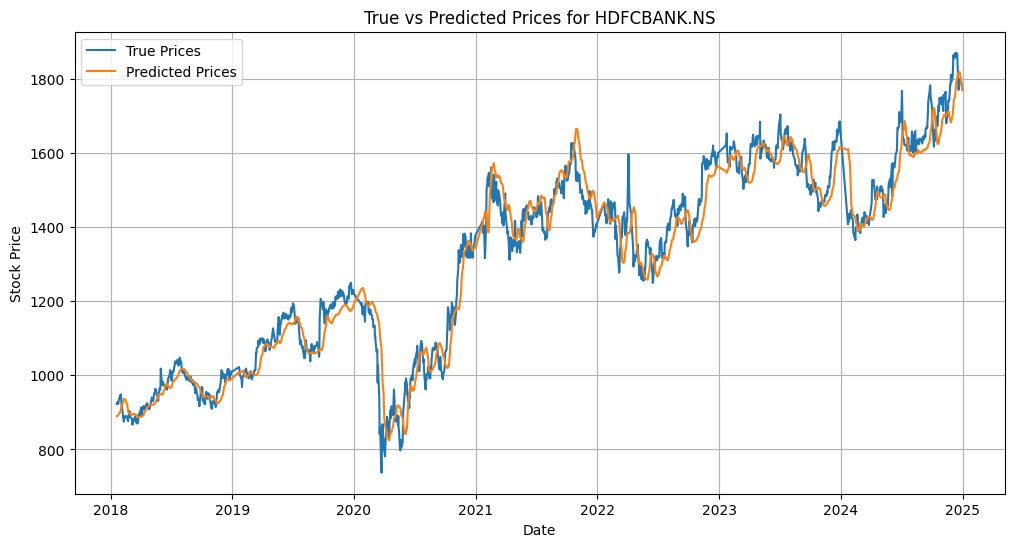

In [65]:
def evaluate_and_return_predictions(model_name, test_data, test_dates, lookback, horizon):
    """
    Evaluate the model on the test data and return predictions.
    
    Args:
        model_name (str): Name of the saved model (e.g., 'StockA_20150101_20180101').
        test_data (np.array): Test data for evaluation.
        test_dates (pd.DatetimeIndex): Dates corresponding to the test data.
        lookback (int): Number of past days to consider.
        horizon (int): Horizon for prediction (5 for fifth day).
    
    Returns:
        np.array: Predicted prices.
        np.array: Actual prices.
        np.array: Dates corresponding to the predictions.
    """
    # Load the model
    model = load_model(f"{model_name}.h5")

    # Load the scaler
    scaler = joblib.load(f"{model_name}_scaler.pkl")

    # Prepare the test data
    scaled_test_data = scaler.transform(test_data)
    X_test, y_test = create_dataset(scaled_test_data, lookback, horizon)

    # Reshape data for LSTM
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Make predictions
    scaled_predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(scaled_predictions)  # Reverse scaling for predictions
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))   # Reverse scaling for actual values

    # Get dates for the predictions
    prediction_dates = test_dates[lookback + horizon - 1:lookback + horizon - 1 + len(actual)]

    return predictions.flatten(), actual.flatten(), prediction_dates

# Function to plot true vs predicted prices
def plot_true_vs_predicted(true_prices, predicted_prices, dates, model_name):
    """
    Plot true vs predicted prices.
    
    Args:
        true_prices (list): List of true prices.
        predicted_prices (list): List of predicted prices.
        dates (list): List of dates corresponding to the prices.
        model_name (str): Name of the model.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(dates, true_prices, label='True Prices')
    plt.plot(dates, predicted_prices, label='Predicted Prices')
    plt.title(f"True vs Predicted Prices for {model_name}")
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
stock_name = stocks.columns[0]

true_prices = []
predicted_prices = []
all_dates = []

for i in range(len(training_dates)):
    train_start, train_end = training_dates[i][0].strftime('%Y%m%d'), training_dates[i][1].strftime('%Y%m%d')
    test_start, test_end = testing_dates[i][0].strftime('%Y%m%d'), testing_dates[i][1].strftime('%Y%m%d')
    model_name = f"{stock_name}_{train_start}_{test_start}"

    test_data = stocks.loc[test_start:test_end][stock_name].values.reshape(-1, 1)
    test_dates = stocks.loc[test_start:test_end].index

    # Evaluate and get predictions
    predictions, actual, prediction_dates = evaluate_and_return_predictions(model_name, test_data, test_dates, lookback, horizon)

    # Append results
    true_prices.extend(actual)
    predicted_prices.extend(predictions)
    all_dates.extend(prediction_dates)

# Plot true vs predicted prices
plot_true_vs_predicted(true_prices, predicted_prices, all_dates, stock_name)


In [ ]:
stock_name = stocks.columns[0]

true_prices = []
predicted_prices = []

for i in range(len(training_dates)):
    train_start, train_end = training_dates[0][0].strftime('%Y%m%d'), training_dates[0][1].strftime('%Y%m%d')
    test_start, test_end = testing_dates[0][0].strftime('%Y%m%d'), testing_dates[0][1].strftime('%Y%m%d')
    model_name = f"{stock_name}_{training_dates}_{testing_dates}"

    test_data = stocks.loc[test_start:test_end][stock_name].values.reshape(-1, 1)
    test_dates = stocks.loc[test_start:test_end].index
    
    true_prices.append(test_data)
    predicted_prices.append(evaluate_and_plot_continuous(model_name, test_data, test_dates, lookback, horizon))

    


1/1 [==============================] - 1s 1s/step
Predicted price for the fifth day: 1346.9600830078125
56/56 [==============================] - 1s 6ms/step
Mean Squared Error (MSE) for HDFCBANK.NS_20150101_20180101: 42153.28137150147


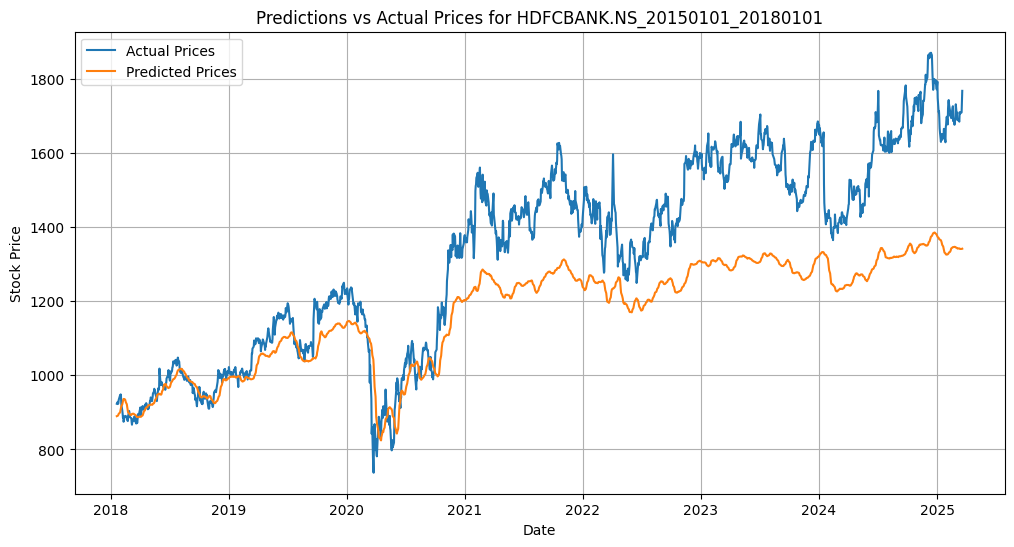

In [55]:
stock_name = stocks.columns[0]
train_start = '20150101'
test_start = '20180101'
model_name = f"{stock_name}_{train_start}_{test_start}"

# Get the last `lookback` days of data for prediction
last_sequence = stocks[stock_name].values[-lookback:].reshape(-1, 1)

# Make prediction
prediction = predict_fifth_day(model_name, last_sequence)
print(f"Predicted price for the fifth day: {prediction}")

# Evaluate and plot for the test data
test_data = stocks.loc[test_start:][stock_name].values.reshape(-1, 1)
test_dates = stocks.loc[test_start:].index
evaluate_and_plot_continuous(model_name, test_data, test_dates, lookback, horizon)

In [56]:
test_start

'20180101'

In [46]:
training_dates[0][0].strftime('%Y%m%d')

'20150101'

In [ ]:
def get_training_testing_date(stock_name, training_dates, testing_dates):
    
    
